In [1]:
import numpy as np
import torch.utils.data
from torchvision.transforms.v2 import RandomCrop
from src.data.dataset import SeverstalSteelDefectDataset

dataset = SeverstalSteelDefectDataset(
    images_path="../data/train_images",
    label_csv="../data/train.csv",
    transform=RandomCrop((256, 1000))
)

Image shape: torch.Size([1, 256, 1000]), Class label: tensor([0, 0, 1, 1])


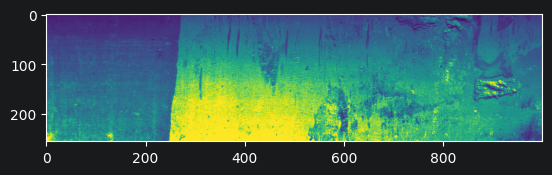

In [2]:
from matplotlib.pyplot import imshow
sample = dataset[5]
imshow(sample[0].permute(1, 2, 0))
print(f"Image shape: {sample[0].shape}, Class label: {sample[1]}")

In [3]:
from src.data.split import stratified_train_test_split

train, val = stratified_train_test_split(dataset, test_size=0.2, random_state=42)

print(f"Train size: {len(train)}")
print(f"Validation size: {len(val)}")

# class distribution of each set
train_labels = [label for _, label in train]
val_labels = [label for _, label in val]

print(f"Train class distribution: {dict(sorted({label: train_labels.count(label) for label in set(train_labels)}.items()))}")
print(f"Validation class distribution: {dict(sorted({label: val_labels.count(label) for label in set(val_labels)}.items()))}")

TypeError: stratified_train_test_split() missing 1 required positional argument: 'labels'

In [ ]:
import numpy as np

print(f"Class distribution: {dict(zip(*np.unique(dataset.targets, return_counts=True)))}")

In [25]:
import pandas as pd
labels = pd.read_csv("../data/train.csv", sep=",", iterator=False)
torch.nn.functional.one_hot(labels.groupby("ImageId").agg(list).iloc(1)., num_classes=4)

TypeError: one_hot(): argument 'input' (position 1) must be Tensor, not _iLocIndexer

In [46]:
torch.sum(torch.nn.functional.one_hot(torch.from_numpy(labels.groupby("ImageId").agg(list)['ClassId'].values), num_classes=4), dim=0)

ValueError: Must produce aggregated value

In [44]:
labels.groupby("ImageId").agg(list)['ClassId'].values

array([list([1]), list([3]), list([1]), ..., list([3]), list([3]),
       list([3])], shape=(6666,), dtype=object)